In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
btc = yf.download("BTC-USD", period="730d", interval="1h", auto_adjust=False)
gld = yf.download("GLD", period="730d", interval="1h", auto_adjust=False)

print("BTC shape:", btc.shape)
print("GLD shape:", gld.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

BTC shape: (17351, 6)
GLD shape: (5077, 6)


In [3]:
btc.columns = btc.columns.get_level_values(0)
gld.columns = gld.columns.get_level_values(0)

btc.head(), gld.head()

(Price                         Adj Close         Close          High  \
 Datetime                                                              
 2024-04-05 00:00:00+00:00  68685.078125  68685.078125  68718.742188   
 2024-04-05 01:00:00+00:00  68208.515625  68208.515625  68658.070312   
 2024-04-05 02:00:00+00:00  67595.914062  67595.914062  68197.523438   
 2024-04-05 03:00:00+00:00  67868.046875  67868.046875  68002.406250   
 2024-04-05 04:00:00+00:00  67638.500000  67638.500000  68032.492188   
 
 Price                               Low          Open     Volume  
 Datetime                                                          
 2024-04-05 00:00:00+00:00  68196.898438  68520.156250          0  
 2024-04-05 01:00:00+00:00  67905.335938  68658.070312  446054400  
 2024-04-05 02:00:00+00:00  67490.976562  68197.523438   81485824  
 2024-04-05 03:00:00+00:00  67632.820312  67632.820312  330457088  
 2024-04-05 04:00:00+00:00  67518.351562  67876.218750          0  ,
 Price           

In [4]:
print(btc.columns)
print(gld.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [5]:
btc_1h = btc[["Close"]].copy()
gld_1h = gld[["Close"]].copy()

btc_1h.index = btc_1h.index.floor("1h")
gld_1h.index = gld_1h.index.floor("1h")

btc_1h.columns.name = None
gld_1h.columns.name = None

btc_1h = btc_1h.rename(columns={"Close": "btc_close"})
gld_1h = gld_1h.rename(columns={"Close": "gld_close"})

print(btc_1h.head())
print(gld_1h.head())

                              btc_close
Datetime                               
2024-04-05 00:00:00+00:00  68685.078125
2024-04-05 01:00:00+00:00  68208.515625
2024-04-05 02:00:00+00:00  67595.914062
2024-04-05 03:00:00+00:00  67868.046875
2024-04-05 04:00:00+00:00  67638.500000
                            gld_close
Datetime                             
2023-05-05 13:00:00+00:00  186.610001
2023-05-05 14:00:00+00:00  186.910004
2023-05-05 15:00:00+00:00  187.110001
2023-05-05 16:00:00+00:00  187.419998
2023-05-05 17:00:00+00:00  187.210007


In [6]:
common_index = btc_1h.index.intersection(gld_1h.index)

btc_sync = btc_1h.loc[common_index].copy()
gld_sync = gld_1h.loc[common_index].copy()

print("BTC sync shape:", btc_sync.shape)
print("GLD sync shape:", gld_sync.shape)
print("Start:", common_index.min())
print("End:", common_index.max())

BTC sync shape: (3447, 1)
GLD sync shape: (3447, 1)
Start: 2024-04-05 13:00:00+00:00
End: 2026-04-02 19:00:00+00:00


In [7]:
df = btc_sync.join(gld_sync, how="inner")

print("Merged shape:", df.shape)
df.head()

Merged shape: (3447, 2)


,btc_close,gld_close
Datetime,,
2024-04-05 13:00:00+00:00,67558.523438,213.970001
2024-04-05 14:00:00+00:00,68233.859375,215.199997
2024-04-05 15:00:00+00:00,68102.609375,215.240005
2024-04-05 16:00:00+00:00,67923.015625,215.279999
2024-04-05 17:00:00+00:00,67458.890625,215.340103


In [8]:
df["btc_ret_1h"] = df["btc_close"].pct_change()
df["gld_ret_1h"] = df["gld_close"].pct_change()

df = df.dropna().copy()

df.head()

,btc_close,gld_close,btc_ret_1h,gld_ret_1h
Datetime,,,,
2024-04-05 14:00:00+00:00,68233.859375,215.199997,0.009996,0.005748
2024-04-05 15:00:00+00:00,68102.609375,215.240005,-0.001924,0.000186
2024-04-05 16:00:00+00:00,67923.015625,215.279999,-0.002637,0.000186
2024-04-05 17:00:00+00:00,67458.890625,215.340103,-0.006833,0.000279
2024-04-05 18:00:00+00:00,67585.554688,215.059998,0.001878,-0.001301


In [9]:
df_4h = df.resample("4h").agg({
    "btc_close": "last",
    "gld_close": "last",
    "btc_ret_1h": "sum",
    "gld_ret_1h": "sum"
}).dropna().copy()

print("4H shape:", df_4h.shape)
df_4h.head()

4H shape: (1151, 4)


,btc_close,gld_close,btc_ret_1h,gld_ret_1h
Datetime,,,,
2024-04-05 12:00:00+00:00,68102.609375,215.240005,0.008073,0.005934
2024-04-05 16:00:00+00:00,67535.945312,215.110001,-0.008327,-0.000603
2024-04-08 12:00:00+00:00,71758.664062,215.589996,0.062689,0.002232
2024-04-08 16:00:00+00:00,71656.507812,216.475006,-0.001410,0.004107
2024-04-09 12:00:00+00:00,69157.882812,217.235001,-0.035167,0.003572


In [10]:
df_4h["btc_ret_4h"] = df_4h["btc_close"].pct_change()
df_4h["gld_ret_4h"] = df_4h["gld_close"].pct_change()

df_4h["btc_vol_12"] = df_4h["btc_ret_4h"].rolling(12).std()
df_4h["gld_vol_12"] = df_4h["gld_ret_4h"].rolling(12).std()

df_4h = df_4h.dropna().copy()

print("Final 4H shape:", df_4h.shape)
df_4h.head()

Final 4H shape: (1139, 8)


,btc_close,gld_close,btc_ret_1h,gld_ret_1h,btc_ret_4h,gld_ret_4h,btc_vol_12,gld_vol_12
Datetime,,,,,,,,
2024-04-15 12:00:00+00:00,64538.929688,217.404999,-0.038711,0.002413,-0.038445,0.002374,0.027252,0.006424
2024-04-15 16:00:00+00:00,63519.015625,220.929993,-0.015827,0.016141,-0.015803,0.016214,0.027442,0.007770
2024-04-16 12:00:00+00:00,61914.695312,221.139999,-0.025451,0.001010,-0.025257,0.000951,0.017926,0.007779
2024-04-16 16:00:00+00:00,62777.230469,221.220001,0.013930,0.000366,0.013931,0.000362,0.019254,0.007769
2024-04-17 12:00:00+00:00,60446.308594,220.270004,-0.037492,-0.004296,-0.037130,-0.004294,0.019521,0.007941


In [11]:
features = ["btc_ret_4h", "btc_vol_12", "gld_ret_4h", "gld_vol_12"]

df_model = df_4h[features].copy()

print(df_model.shape)
df_model.head()

(1139, 4)


,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12
Datetime,,,,
2024-04-15 12:00:00+00:00,-0.038445,0.027252,0.002374,0.006424
2024-04-15 16:00:00+00:00,-0.015803,0.027442,0.016214,0.007770
2024-04-16 12:00:00+00:00,-0.025257,0.017926,0.000951,0.007779
2024-04-16 16:00:00+00:00,0.013931,0.019254,0.000362,0.007769
2024-04-17 12:00:00+00:00,-0.037130,0.019521,-0.004294,0.007941


In [12]:
env_df = df_4h[[
    "btc_close",
    "btc_ret_4h",
    "btc_vol_12",
    "gld_ret_4h",
    "gld_vol_12"
]].copy()

print(env_df.shape)
env_df.head()

(1139, 5)


,btc_close,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12
Datetime,,,,,
2024-04-15 12:00:00+00:00,64538.929688,-0.038445,0.027252,0.002374,0.006424
2024-04-15 16:00:00+00:00,63519.015625,-0.015803,0.027442,0.016214,0.007770
2024-04-16 12:00:00+00:00,61914.695312,-0.025257,0.017926,0.000951,0.007779
2024-04-16 16:00:00+00:00,62777.230469,0.013931,0.019254,0.000362,0.007769
2024-04-17 12:00:00+00:00,60446.308594,-0.037130,0.019521,-0.004294,0.007941


In [13]:
btc_features = ["btc_ret_4h", "btc_vol_12"]
env_btc = env_df[["btc_close"] + btc_features].copy()

print(env_btc.shape)
env_btc.head()

(1139, 3)


,btc_close,btc_ret_4h,btc_vol_12
Datetime,,,
2024-04-15 12:00:00+00:00,64538.929688,-0.038445,0.027252
2024-04-15 16:00:00+00:00,63519.015625,-0.015803,0.027442
2024-04-16 12:00:00+00:00,61914.695312,-0.025257,0.017926
2024-04-16 16:00:00+00:00,62777.230469,0.013931,0.019254
2024-04-17 12:00:00+00:00,60446.308594,-0.037130,0.019521


In [14]:
btc_gld_features = ["btc_ret_4h", "btc_vol_12", "gld_ret_4h", "gld_vol_12"]
env_btc_gld = env_df[["btc_close"] + btc_gld_features].copy()

print(env_btc_gld.shape)
env_btc_gld.head()

(1139, 5)


,btc_close,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12
Datetime,,,,,
2024-04-15 12:00:00+00:00,64538.929688,-0.038445,0.027252,0.002374,0.006424
2024-04-15 16:00:00+00:00,63519.015625,-0.015803,0.027442,0.016214,0.007770
2024-04-16 12:00:00+00:00,61914.695312,-0.025257,0.017926,0.000951,0.007779
2024-04-16 16:00:00+00:00,62777.230469,0.013931,0.019254,0.000362,0.007769
2024-04-17 12:00:00+00:00,60446.308594,-0.037130,0.019521,-0.004294,0.007941


In [15]:
split_idx = int(len(env_df) * 0.8)

train_btc = env_btc.iloc[:split_idx].copy()
test_btc  = env_btc.iloc[split_idx:].copy()

train_btc_gld = env_btc_gld.iloc[:split_idx].copy()
test_btc_gld  = env_btc_gld.iloc[split_idx:].copy()

print("train_btc:", train_btc.shape)
print("test_btc:", test_btc.shape)
print("train_btc_gld:", train_btc_gld.shape)
print("test_btc_gld:", test_btc_gld.shape)

train_btc: (911, 3)
test_btc: (228, 3)
train_btc_gld: (911, 5)
test_btc_gld: (228, 5)


In [16]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from env.trading_env import TradingEnv

In [ ]:
btc_feature_columns = ["btc_ret_4h", "btc_vol_12"]

env_train_btc_ra = TradingEnv(
    data=train_btc,
    feature_columns=btc_feature_columns,
    price_column="btc_close",
    transaction_cost=0.0,
    reward_mode="risk_adjusted",
)

obs, info = env_train_btc_ra.reset()
print("Initial observation:", obs)
print("Observation shape:", obs.shape)
print("Info:", info)

Initial observation: [-0.03844539  0.0272524   0.        ]
Observation shape: (3,)
Info: {}


In [ ]:
obs, reward, done, truncated, info = env_train_btc_ra.step(1)  # long
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

obs, reward, done, truncated, info = env_train_btc_ra.step(0)  # hold
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Reward: -0.016803082998718244
Done: False
Info: {'step': 1, 'position': 1, 'asset_return': np.float64(-0.015803082998718243)}
Reward: -0.025257323286801192
Done: False
Info: {'step': 2, 'position': 1, 'asset_return': np.float64(-0.025257323286801192)}


In [ ]:
btc_gld_feature_columns = ["btc_ret_4h", "btc_vol_12", "gld_ret_4h", "gld_vol_12"]

env_train_btc_gld_ra = TradingEnv(
    data=train_btc_gld,
    feature_columns=btc_gld_feature_columns,
    price_column="btc_close",
    transaction_cost=0.0,
    reward_mode="risk_adjusted",
)


obs, info = env_train_btc_gld_ra.reset()
print("Initial observation:", obs)
print("Observation shape:", obs.shape)
print("Info:", info)

Initial observation: [-0.03844539  0.0272524   0.00237447  0.00642365  0.        ]
Observation shape: (5,)
Info: {}


In [ ]:
obs, reward, done, truncated, info = env_train_btc_gld_ra.step(1)
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Reward: -0.016803082998718244
Done: False
Info: {'step': 1, 'position': 1, 'asset_return': np.float64(-0.015803082998718243)}


In [ ]:
env_test_btc_ra = TradingEnv(
    data=test_btc,
    feature_columns=btc_feature_columns,
    price_column="btc_close",
    transaction_cost=0.0,
    reward_mode="risk_adjusted",
)

env_test_btc_gld_ra = TradingEnv(
    data=test_btc_gld,
    feature_columns=btc_gld_feature_columns,
    price_column="btc_close",
    transaction_cost=0.0,
    reward_mode="risk_adjusted",
)

In [22]:
from stable_baselines3 import PPO

In [ ]:
model_btc_ra = PPO(
    "MlpPolicy",
    env_train_btc_ra,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_btc_ra.learn(total_timesteps=50000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 1062 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 826          |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0017962272 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | -5.87        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.00841      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0022      |
|    val

In [ ]:
model_btc_gld_ra = PPO(
    "MlpPolicy",
    env_train_btc_gld_ra,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_btc_gld_ra.learn(total_timesteps=50000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 632 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 527         |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 0.005452213 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.1        |
|    explained_variance   | -9.1        |
|    learning_rate        | 0.0003      |
|    loss                 | -0.00941    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00556    |
|    value_loss           | 0.0

In [ ]:
model_btc_ra.save("../results/model_btc_baseline")
model_btc_gld_ra.save("../results/model_btc_gld")

In [ ]:
import numpy as np
import pandas as pd

def evaluate_model(model, env, data_df):
    obs, info = env.reset()

    done = False
    truncated = False

    equity = [1.0]
    rewards = []
    positions = []
    asset_returns = []
    actions = []

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(int(action))

        rewards.append(reward)
        actions.append(int(action))
        positions.append(info["position"])
        asset_returns.append(info["asset_return"])

        equity.append(equity[-1] * (1.0 + reward))

    results = pd.DataFrame({
        "reward": rewards,
        "position": positions,
        "asset_return": asset_returns,
        "action": actions,
    }, index=data_df.index[1:1+len(rewards)])

    results["equity"] = equity[1:]
    return results

In [ ]:
results_btc = evaluate_model(model_btc_ra, env_test_btc_ra, test_btc)
results_btc_gld = evaluate_model(model_btc_gld_ra, env_test_btc_gld_ra, test_btc_gld)

results_btc.head(), results_btc_gld.head()

(                           reward  position  asset_return  action  equity
 Datetime                                                                 
 2025-12-03 20:00:00+00:00    -0.0         0     -0.001096       0     1.0
 2025-12-04 12:00:00+00:00     0.0         0      0.001011       0     1.0
 2025-12-04 16:00:00+00:00    -0.0         0     -0.010522       0     1.0
 2025-12-04 20:00:00+00:00     0.0         0      0.005439       0     1.0
 2025-12-05 12:00:00+00:00    -0.0         0     -0.023877       0     1.0,
                              reward  position  asset_return  action    equity
 Datetime                                                                     
 2025-12-03 20:00:00+00:00 -0.002096         1     -0.001096       1  0.997904
 2025-12-04 12:00:00+00:00  0.001011         1      0.001011       1  0.998912
 2025-12-04 16:00:00+00:00 -0.010522         1     -0.010522       1  0.988402
 2025-12-04 20:00:00+00:00  0.005439         1      0.005439       1  0.993778


In [28]:
results_btc["action"].value_counts()
results_btc_gld["action"].value_counts()

action
1    227
Name: count, dtype: int64

In [29]:
def compute_metrics(results_df, periods_per_year=252*2):
    rets = results_df["reward"].dropna()

    cumulative_return = (1 + rets).prod() - 1

    mean_ret = rets.mean()
    vol = rets.std()

    sharpe = np.nan
    if vol > 0:
        sharpe = (mean_ret / vol) * np.sqrt(periods_per_year)

    downside = rets[rets < 0].std()
    sortino = np.nan
    if downside > 0:
        sortino = (mean_ret / downside) * np.sqrt(periods_per_year)

    equity = results_df["equity"]
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    position_changes = results_df["position"].diff().fillna(0)
    initial_trade = 1 if results_df["position"].iloc[0] != 0 else 0
    n_trades = int((position_changes != 0).sum() + initial_trade)

    return {
        "cumulative_return": cumulative_return,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_drawdown,
        "n_trades": int(n_trades),
    }

In [30]:
metrics_btc = compute_metrics(results_btc)
metrics_btc_gld = compute_metrics(results_btc_gld)

metrics_btc, metrics_btc_gld

({'cumulative_return': np.float64(0.0),
  'sharpe': nan,
  'sortino': nan,
  'max_drawdown': np.float64(0.0),
  'n_trades': 0},
 {'cumulative_return': np.float64(-0.2801516303770851),
  'sharpe': np.float64(-1.5384355109374677),
  'sortino': np.float64(-2.0437988207655313),
  'max_drawdown': np.float64(-0.34884352553147935),
  'n_trades': 1})

In [31]:
comparison = pd.DataFrame([metrics_btc, metrics_btc_gld], index=["BTC", "BTC+GLD"])
comparison

,cumulative_return,sharpe,sortino,max_drawdown,n_trades
BTC,0.000000,NaN,NaN,0.000000,0
BTC+GLD,-0.280152,-1.538436,-2.043799,-0.348844,1


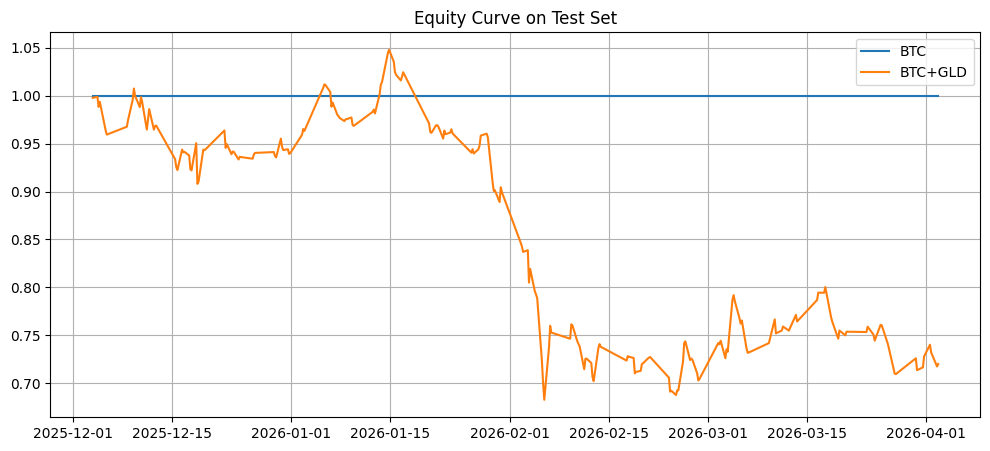

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(results_btc.index, results_btc["equity"], label="BTC")
plt.plot(results_btc_gld.index, results_btc_gld["equity"], label="BTC+GLD")
plt.title("Equity Curve on Test Set")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
buy_hold_ret = test_btc["btc_close"].iloc[-1] / test_btc["btc_close"].iloc[0] - 1
print("Buy & Hold return:", buy_hold_ret)

Buy & Hold return: -0.2794302699733495


In [34]:
print("BTC actions:")
print(results_btc["action"].value_counts())

print("\nBTC+GLD actions:")
print(results_btc_gld["action"].value_counts())

print("\nBTC positions:")
print(results_btc["position"].value_counts())

print("\nBTC+GLD positions:")
print(results_btc_gld["position"].value_counts())

BTC actions:
action
0    227
Name: count, dtype: int64

BTC+GLD actions:
action
1    227
Name: count, dtype: int64

BTC positions:
position
0    227
Name: count, dtype: int64

BTC+GLD positions:
position
1    227
Name: count, dtype: int64
